In [1]:
using Rasters
# Usa internamente DiskArrays.jl 
#   Cuando cargas un NetCDF grande, Julia crea una "vista" del disco duro

using NCDatasets
using Printf
using Statistics


# -------------------------------------------------------------------------
# Rutas
# -------------------------------------------------------------------------

path = "./data_heavy/"
ncname = "download5Dcolombia"
ncfile5d = joinpath(path, ncname * ".nc")
zipfile = joinpath(path, ncname * ".zip")

# -------------------------------------------------------------------------
# Control de archivos
# -------------------------------------------------------------------------

if !isfile(ncfile5d)
    if !isfile(zipfile)
        error("No existe .nc ni .zip")
    end
else
    println("Usando archivo existente")
end


# -------------------------------------------------------------------------
# Carga lazy
# -------------------------------------------------------------------------

# Dimensiones: X, Y, Z (level), Int (number), Ti (time)
cube = Raster(ncfile5d); nothing

# -------------------------------------------------------------------------
# Dimensiones
# -------------------------------------------------------------------------

println("\n=== DIMENSIONES ===")
println(Rasters.dims(cube))

# -------------------------------------------------------------------------
# Variable
# -------------------------------------------------------------------------

println("\n=== VARIABLE ===")
println(Rasters.name(cube))

# -------------------------------------------------------------------------
# Metadatos
# -------------------------------------------------------------------------

println("\n=== METADATOS ===")
println(Rasters.metadata(cube))

# -------------------------------------------------------------------------
# Shape
# -------------------------------------------------------------------------

println("\n=== SHAPE ===")
println(size(cube))

# -------------------------------------------------------------------------
# Niveles
# -------------------------------------------------------------------------

z_levels = dims(cube, Z); nothing

println("\nPrimeros niveles:")
println(z_levels[1:2])

println("\nÚltimos niveles:")
println(z_levels[end-1:end])

Usando archivo existente

=== DIMENSIONES ===
(↓ X Mapped{Float32} [-79.1f0, …, -67.1f0] ForwardOrdered Regular Points,
→ Y Mapped{Float32} [12.5f0, …, -4.5f0] ReverseOrdered Regular Points,
↗ Z Sampled{Int32} [1, …, 1000] ForwardOrdered Irregular Points,
⬔ number Sampled{Int32} [0, …, 9] ForwardOrdered Regular Points,
◩ Ti Sampled{Dates.DateTime} [Dates.DateTime("2020-01-01T00:00:00"), …, Dates.DateTime("2020-02-29T21:00:00")] ForwardOrdered Irregular Points)

=== VARIABLE ===
t

=== METADATOS ===
DimensionalData.Dimensions.Lookups.Metadata{Rasters.NCDsource, Dict{String, Any}}(Dict{String, Any}("missing_value" => -32767, "units" => "K", "add_offset" => 249.09367691600488, "long_name" => "Temperature", "scale_factor" => 0.001961963888675958, "standard_name" => "air_temperature", "_FillValue" => -32767))

=== SHAPE ===
(25, 35, 37, 10, 480)

Primeros niveles:
Z{DimensionalData.Dimensions.Lookups.Sampled{Int32, Vector{Int32}, DimensionalData.Dimensions.Lookups.ForwardOrdered, Dimensiona

In [ ]:
cube

Union{Missing, Float64}[263.9535914088366;;]
(:X, :Y)
(Float32[-74.1], Float32[4.5])
Float32[-74.1]
Float32[4.5]
Valores en la dimensión X: Float32[-74.1]
Valores en la dimensión Y: Float32[4.5]


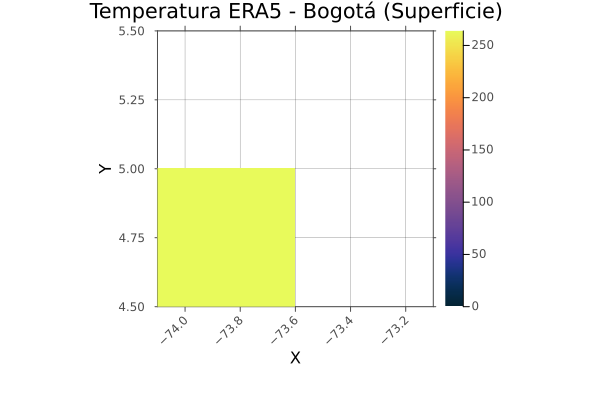

In [4]:
# ============================================================
# Selección avanzada en cubo 5D (ERA5) con Rasters.jl
# - Selección por dimensiones (Z, Ti, number)
# - Recorte espacial (Bogotá)
# - Extracción implícita de variable
# - Reducción a slice 2D + Visualización
# ============================================================

using Rasters
# Usa internamente DiskArrays.jl 
#   Cuando cargas un NetCDF grande, Julia crea una "vista" del disco duro

using Plots

# -------------------------------------------------------------------------
# Selección 1: Subconjunto por dimensiones
# -------------------------------------------------------------------------
# En Julia, específicamente en el ecosistema de Rasters.jl y DimensionalData.jl, existen dos tipos de dimensiones:
# - Dimensiones Estándar: Son "atajos" predefinidos para los ejes más comunes: X, Y, Z y Ti (para el tiempo). 
# Por eso puedes usarlos directamente como Z(1) o Ti(1).
# - Dimensiones Genéricas (Custom): Cualquier otra dimensión que venga en un NetCDF (como number, ensemble, 
#   level_str, etc.) no tiene un "atajo" de una sola letra. Para referirte a ellas, debes usar el constructor 
#   genérico Dim{:nombre_de_la_variable}.
#

# Selecciona:
# - niveles 1:2
# - tiempo 1

# Los recortes con cube[...] su puramente perezosos
sel_dim = cube[Z(1:2), Ti(1)]; nothing

# -------------------------------------------------------------------------
# Selección 2: Recorte espacial (Bogotá)
# -------------------------------------------------------------------------
# Filtrado por rango en coordenadas
# Between permite filtrar rangos espaciales directamente
# Los recortes con cube[...] su puramente perezosos
sel_bogota = cube[
    X(Between(-74.25, -73.90)),
    Y(Between(4.45, 4.85))
]; nothing

# -------------------------------------------------------------------------
# Slice 2D
# -------------------------------------------------------------------------
# Selecciona:
# - último nivel (superficie): Z(37) -> Nivel de 1000 hPa (superficie)
# - miembro de ensamble 1: Dim{:number}(1) -> Miembro de ensamble de control
# - tiempo 1: Ti(1)  -> Primer paso de tiempo.
#
# Nota: Si usaras solo - number(1) - Julia daría error porque "number" no es un tipo definido.
capa_2d = sel_bogota[Z(end), Dim{:number}(1), Ti(1)]

# Visualización de la matriz de datos (arreglo de Julia)
println(parent(capa_2d))

# Verificación de las dimensiones restantes
# Nota: escribir f.(x) es equivalente a invocar broadcast
println(Rasters.name.(dims(capa_2d)))

# Verificación de los valores de las coordenadas
# Nota: escribir f.(x) es equivalente a invocar broadcast
println(lookup.(dims(capa_2d)))

# Extracción de los valores de longitud (X) y latitud (Y)
# Se asume el uso de selectores DimensionalData.X y DimensionalData.Y
eje_x = lookup(capa_2d, X)
eje_y = lookup(capa_2d, Y)

println(eje_x)
println(eje_y)

# Verificación y extracción robusta
for d in dims(capa_2d)
    nom = Rasters.name(d)
    vals = lookup(d)
    println("Valores en la dimensión $nom: $vals")
end

# -------------------------------------------------------------------------
# Visualización
# -------------------------------------------------------------------------
# Objeto ya reducido a 2D (X, Y)

p_5d = plot(
    capa_2d,
    title = "Temperatura ERA5 - Bogotá (Superficie)",
    c = :thermal,
    xrotation=45,
    bottom_margin=10Plots.mm
)

display(p_5d)